In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import numpy as np
import random

from tqdm import tqdm
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [2]:
TRAJECTORY_LEN = 1001

In [3]:
def reset_to_location(env, location):
    env.sim.reset()
    qpos = env.init_qpos + env.np_random.uniform(low=-.1, high=.1, size=env.model.nq)
    qpos[:2] = np.array(location).astype(env.observation_space.dtype)
    qvel = env.init_qvel + env.np_random.randn(env.model.nv) * .1
    env.set_state(qpos, qvel)
    return env.unwrapped._get_obs()

In [4]:
import gym
import d4rl # Import required to register environments, you may need to also import the submodule

# Create the environment
env = gym.make('antmaze-large-diverse-v2')
dataset = env.get_dataset()

/home/nazim/.local/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:9: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.spawn
/home/nazim/.local/lib/python3.10/site-packages/mujoco_py/builder.py:9: DeprecationWarning: The distutils.sysconfig module is deprecated, use sysconfig instead
  from distutils.sysconfig import customize_compiler
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead
No module named 'flow'
No module named 'carla'
pybullet build time: Jan 29 2025 23:16:28
/home/nazim/.local/lib/python3.10/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Target Goal:  (32.56037435911033, 25.201456159629828)


load datafile: 100%|██████████| 8/8 [00:01<00:00,  5.21it/s]


In [5]:
x = dataset['observations']
coord_0_min, coord_0_max, coord_1_min, coord_1_max = x[:, 0].min(), x[:, 0].max(), x[:, 1].min(), x[:, 1].max()


def normalize_dataset_coords(dataset):
    # dataset[..., 0] = ((dataset[..., 0] - coord_0_min) / (coord_0_max - coord_0_min) - 0.5) * 20
    # dataset[..., 1] = ((dataset[..., 1] - coord_1_min) / (coord_1_max - coord_1_min) - 0.5) * 20
    return dataset

In [6]:
dataset_trajectories = torch.tensor(dataset['observations'])
dataset_trajectories = normalize_dataset_coords(dataset_trajectories)

dataset_actions = torch.tensor(dataset['actions'])
dataset_terminals = torch.tensor(dataset['terminals'])
dataset_timeouts = torch.tensor(dataset['timeouts'])

dataset_goals = torch.tensor(dataset['infos/goal'])
dataset_goals = normalize_dataset_coords(dataset_goals)



# [:999*1001]

dataset_trajectories = dataset_trajectories[:999*1001].reshape(-1, 1001, 29)
dataset_actions = dataset_actions[:999*1001].reshape(-1, 1001, 8)
dataset_terminals = dataset_terminals[:999*1001]
dataset_timeouts = dataset_timeouts[:999*1001]

stats = {
    'min_0':dataset_trajectories[..., 0].min(), 
    'max_0':dataset_trajectories[..., 0].max(),
    'min_1':dataset_trajectories[..., 1].min(), 
    'max_1':dataset_trajectories[..., 1].max(),
}
# del dataset

# Directional Rewards:

In [7]:
def directional_reward_right(state):
    min, max = stats['min_0'], stats['max_0']
    return (state[..., 0] - min) / (max - min)
    
def directional_reward_left(state):
    return 1 - directional_reward_right(state)
    
def directional_reward_up(state):
    min, max = stats['min_1'], stats['max_1']
    return (state[..., 1] - min) / (max - min)
    
def directional_reward_down(state):
    return 1 - directional_reward_up(state)
    
def directional_reward_up_right(state):
    r = directional_reward_right(state) + directional_reward_up(state)
    return r / 2

def directional_reward_up_left(state):
    r = directional_reward_left(state) + directional_reward_up(state)
    return r / 2

def directional_reward_down_right(state):
    r = directional_reward_right(state) + directional_reward_down(state)
    return r / 2

def directional_reward_down_left(state):
    r = directional_reward_left(state) + directional_reward_down(state)
    return r / 2


# r = directional_reward_up_left(dataset_trajectories[:, ::100])

# plt.scatter(dataset_trajectories[:, ::100, 0], dataset_trajectories[:, ::100, 1], c=r, vmin=0, vmax=1)

In [8]:
reset_locations = np.array([
    [ 0.5,  0.5],
    [ 0.5,  8.5],
    [ 0.5, 16.5],
    [ 0.5, 24.5],
    [12.5,  0.5],
    [12.5,  8.5],
    [12.5, 16.5],
    [12.5, 24.5],
    [20.5,  0.5],
    [20.5,  8.5],
    [20.5, 16.5],
    [20.5, 24.5],
    [28.5,  0.5],
    [28.5,  8.5],
    [28.5, 16.5],
    [28.5, 24.5],
    [36.5,  0.5],
    [36.5,  8.5],
    [36.5, 16.5],
    [36.5, 24.5]
])





# r = goal_reaching_reward(dataset_trajectories[:, ::10], reset_locations[2])
# plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], c=r, vmin=0, vmax=1)

In [9]:
# Goal reaching rewards:
def goal_reaching_reward(state, goal):
    return torch.norm(state[..., :2] - goal, p=2, dim=-1) < 2



# Simplex rewards:
import opensimplex

class SimplexRewardFunction: 
    def __init__(self, num_simplex):
    
        self.simplex_size = num_simplex
        self.simplex_seeds_pos = np.zeros((self.simplex_size, 36, 25))
        self.simplex_seeds_xvel = np.zeros((self.simplex_size, 36, 25))
        self.simplex_seeds_yvel = np.zeros((self.simplex_size, 36, 25))
        self.simplex_best_xy = np.zeros((self.simplex_size, 10, 2))
        print("Generating simplex seeds")
        xi = np.arange(36)
        yi = np.arange(25)  
        for r in tqdm(range(self.simplex_size)):
            opensimplex.seed(r)
            self.simplex_seeds_pos[r] = opensimplex.noise2array(x=xi/20.0, y=yi/20.0).T
            opensimplex.seed(r + self.simplex_size)
            self.simplex_seeds_xvel[r] = opensimplex.noise2array(x=xi/20.0, y=yi/20.0).T
            opensimplex.seed(r + self.simplex_size * 2)
            self.simplex_seeds_yvel[r] = opensimplex.noise2array(x=xi/20.0, y=yi/20.0).T

            best_topn = np.argpartition(self.simplex_seeds_pos[r].flatten(), -10)[-10:] # (10,)
            best_xy = np.array(np.unravel_index(best_topn, self.simplex_seeds_pos[r].shape)).T # (10, 2)
            self.simplex_best_xy[r] = best_xy
        self.simplex_seeds_xvel[np.abs(self.simplex_seeds_xvel) < 0.5] = 0
        self.simplex_seeds_yvel[np.abs(self.simplex_seeds_yvel) < 0.5] = 0
        
        self.simplex_seeds_pos = torch.tensor(self.simplex_seeds_pos)
        self.simplex_seeds_xvel = torch.tensor(self.simplex_seeds_xvel)
        self.simplex_seeds_yvel = torch.tensor(self.simplex_seeds_yvel)
        self.simplex_best_xy = torch.tensor(self.simplex_best_xy)
        
        
        
    def compute_reward(self, states, params):
        
        if isinstance(params, int):
            params = torch.full((*states.shape[:-1], 1), fill_value=params)
        
        assert len(states.shape) == len(params.shape), states.shape # (batch_size, obs_dim) OR (batch_size, num_pairs, obs_dim)
        
        simplex_id = params[..., 0].long()
        x = states[..., 0].long().clip(0, 35)
        y = states[..., 1].long().clip(0, 24)
        simplex = self.simplex_seeds_pos[simplex_id, x, y]
        simplex_xvel = self.simplex_seeds_xvel[simplex_id, x, y]
        simplex_yvel = self.simplex_seeds_yvel[simplex_id, x, y]
        rews = -1 + (simplex > 0.3).float() * 0.5
        xy_vels = states[..., 15:17] * 0.33820298
        rews += xy_vels[...,0] * simplex_xvel + xy_vels[...,1] * simplex_yvel
        # rews = (simplex > 0.3).float()
        return rews # (batch_size,) 
    
    
# simplex_reward_function = SimplexRewardFunction(num_simplex=10)

# rews = simplex_reward_function.compute_reward(dataset_trajectories[:, ::10], 0)
# plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], c=rews)

In [10]:
class VelocityRewardFunction:
    def __init__(self):
        """
        [0, 1] up
        [0, -1] down
        [0, 1] right
        [0, -1] left
        """
        pass
    
    def compute_reward(self, states, direction):
        
        if isinstance(direction, list):
            direction = torch.concat((
                torch.full((*states.shape[:-1], 1), fill_value=direction[0]),
                torch.full((*states.shape[:-1], 1), fill_value=direction[1])
            ), dim=-1)

        assert len(states.shape) == len(direction.shape), states.shape # (batch_size, obs_dim) OR (batch_size, num_pairs, obs_dim)
        xy_vels = states[..., 15:17] * 0.33820298
        
        
        return torch.sum(xy_vels * direction, dim=-1) # (batch_size,)
    
    
# velocity_reward_function = VelocityRewardFunction()


# plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], c='gray')

# i = 10
# rews = velocity_reward_function.compute_reward(dataset_trajectories[i], [-1, 0])
# plt.scatter(dataset_trajectories[i, :, 0], dataset_trajectories[i, :, 1], c=rews, alpha=np.linspace(0, 1, 1001))


In [11]:
class TestRewMatrix:
    def __init__(self):
        self.pos = torch.zeros((36, 25))
        self.xvel = torch.zeros((36, 25))
        self.yvel = torch.zeros((36, 25))

    def compute_reward(self, s, *args):
        rews = torch.zeros_like(s[..., 0]) # (batch, examples)
        # XY Vel Reward
        xy_vels = s[..., 15:17] * 0.33820298
        
        x = s[..., 0].long().clip(0, 35)
        y = s[..., 1].long().clip(0, 23)
        simplex = self.pos[x, y]
        simplex_xvel = self.xvel[x, y]
        simplex_yvel = self.yvel[x, y]
        rews = (simplex > 0.3).float() * 0.5
        rews += xy_vels[...,0] * simplex_xvel + xy_vels[...,1] * simplex_yvel

        return rews


class TestRewPath(TestRewMatrix):
    def __init__(self):
        super().__init__()
        self.pos[3:21, 7:10] = 1
        self.xvel[3:21, 7:10] = -1

        self.pos[0:3, 3:10] = 1
        self.yvel[0:3, 3:10] = -1

        self.pos[0:18, 0:3] = 1
        self.xvel[0:18, 0:3] = 1
        
        
class TestRewLoop(TestRewMatrix):
    def __init__(self):
        super().__init__()
        self.pos[22:33, 14:18] = 1
        self.xvel[22:33, 14:18] = -1

        self.pos[21:, 0:3] = 1
        self.xvel[21:, 0:3] = 1

        self.pos[33:, 3:18] = 1
        self.yvel[33:, 3:18] = 1

        self.pos[18:21, 0:7] = 1
        self.yvel[18:21, 0:7] = -1
        
        
class TestRewMatrixEdges(TestRewMatrix):
    def __init__(self):
        super().__init__()
        self.pos[:3, :] = 1
        self.pos[-3:, :] = 1
        self.pos[:, :3] = 1
        self.pos[:, -3:] = 1
        
        
        
# path_reward_function = TestRewMatrixEdges()

# rews = path_reward_function.compute_reward(dataset_trajectories[:, ::10])
# plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], c=rews)

In [12]:
velocity_reward_function = VelocityRewardFunction()
simplex_reward_function = SimplexRewardFunction(num_simplex=10)

benchmarks = [
    (goal_reaching_reward, 'goal_bottom', np.array([28, 0])),
    (goal_reaching_reward, 'goal_left', np.array([0, 15])),
    (goal_reaching_reward, 'goal_top', np.array([35, 24])),
    (goal_reaching_reward, 'goal_center', np.array([12, 24])), 
    (goal_reaching_reward, 'goal_right', np.array([33, 16])),
    (velocity_reward_function.compute_reward, 'vel_left', [-1, 0]),
    (velocity_reward_function.compute_reward, 'vel_up', [0, 1]),
    (velocity_reward_function.compute_reward, 'vel_down', [0, -1]),
    (velocity_reward_function.compute_reward, 'vel_right', [1, 0]),
    (simplex_reward_function.compute_reward, 'simplex_1', 1),
    (simplex_reward_function.compute_reward, 'simplex_2', 2),
    (simplex_reward_function.compute_reward, 'simplex_3', 3),
    (simplex_reward_function.compute_reward, 'simplex_4', 4),
    (simplex_reward_function.compute_reward, 'simplex_5', 5),
    (TestRewPath().compute_reward, 'path_center', None),
    (TestRewLoop().compute_reward, 'path_loop', None),
    (TestRewMatrixEdges().compute_reward, 'path_edges', None)
]

Generating simplex seeds


100%|██████████| 10/10 [00:00<00:00, 21.91it/s]


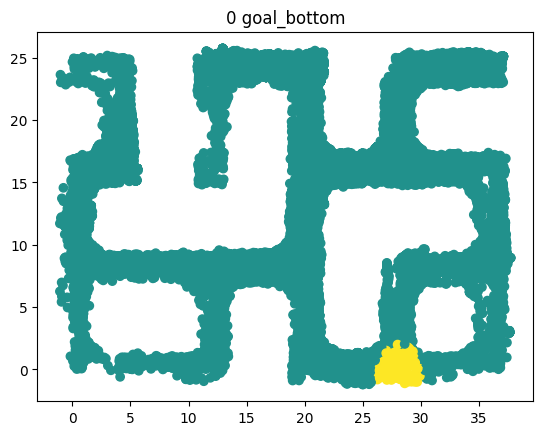

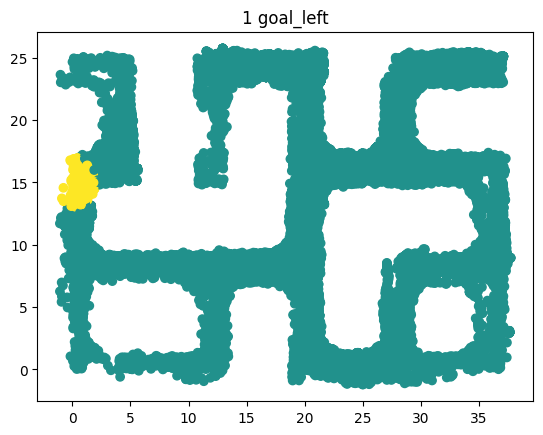

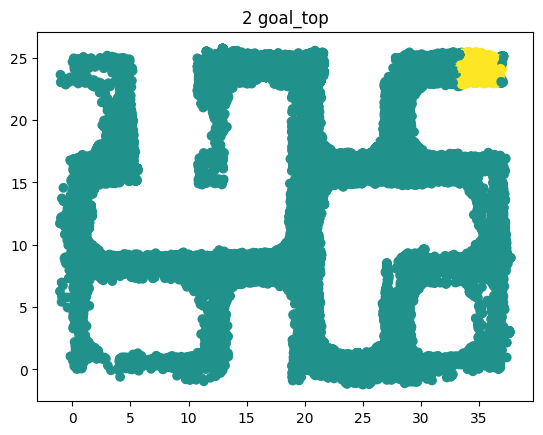

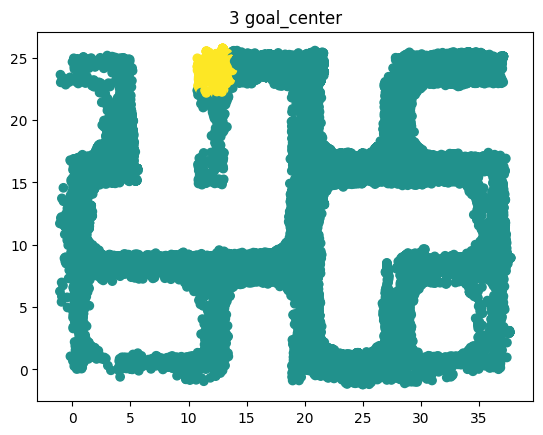

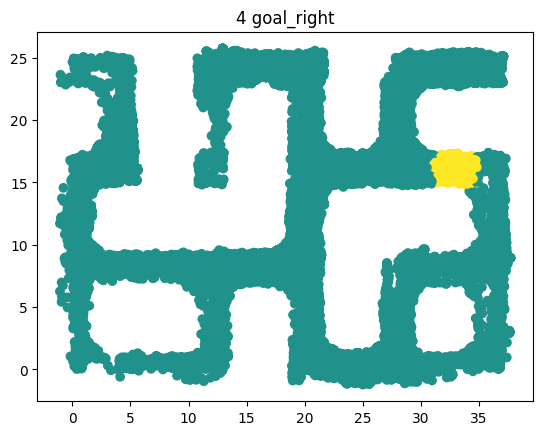

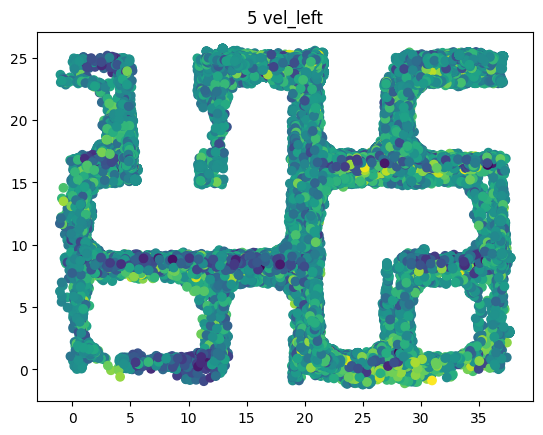

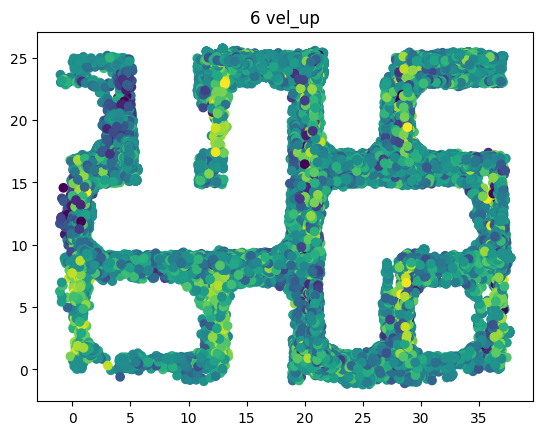

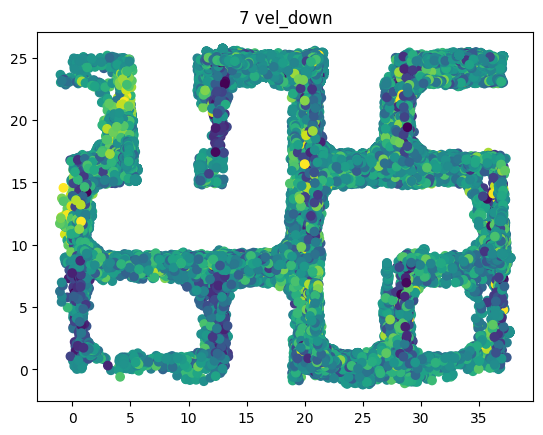

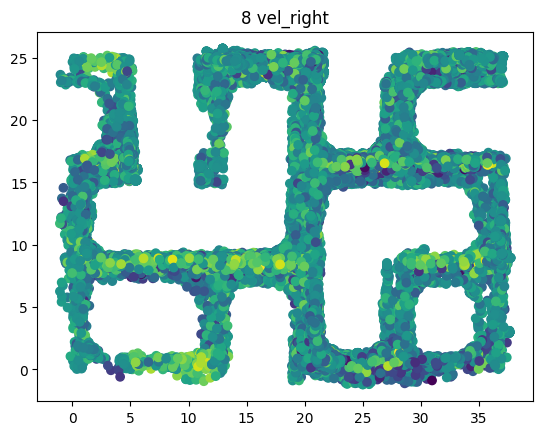

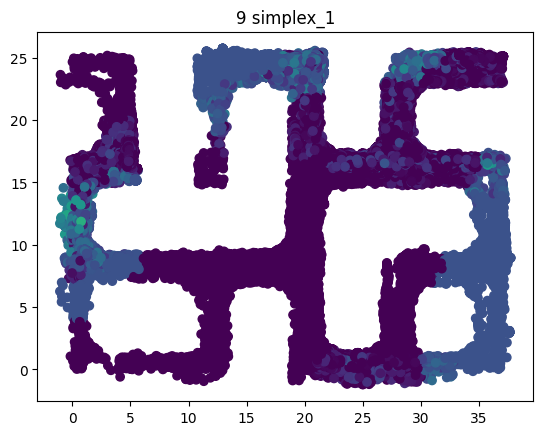

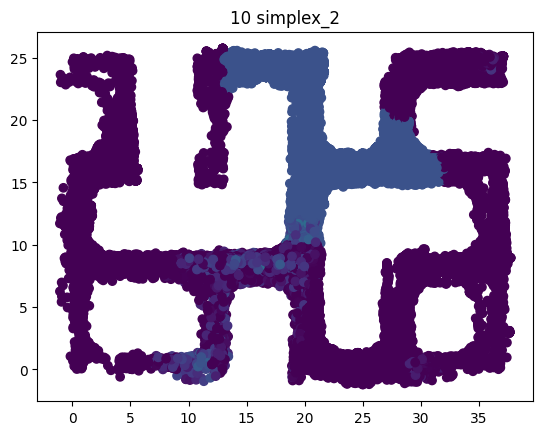

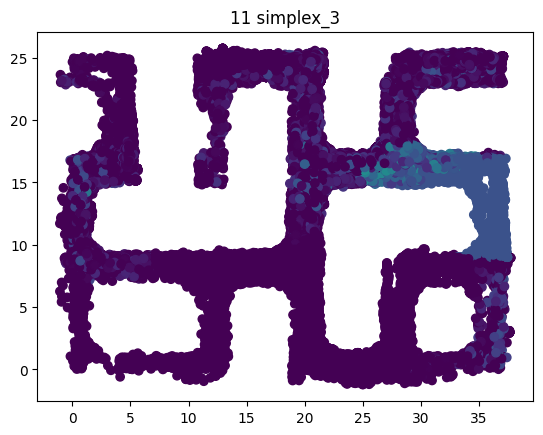

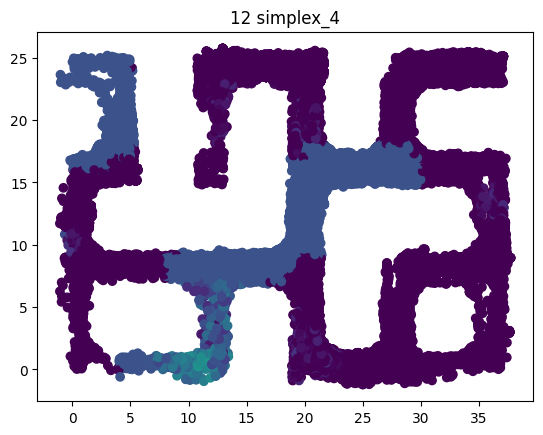

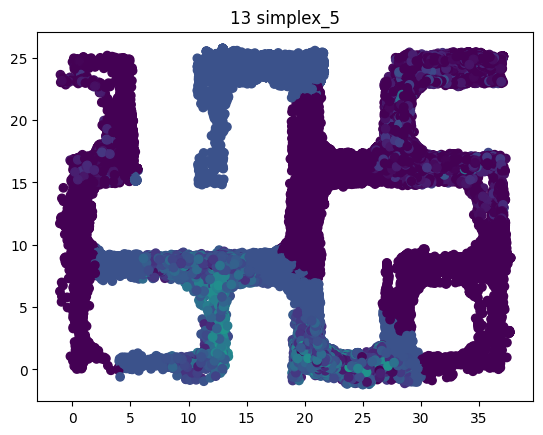

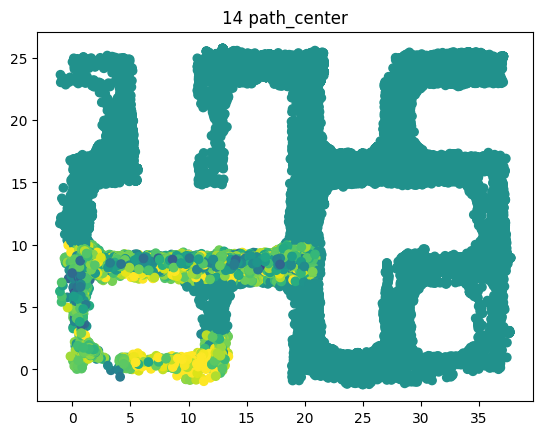

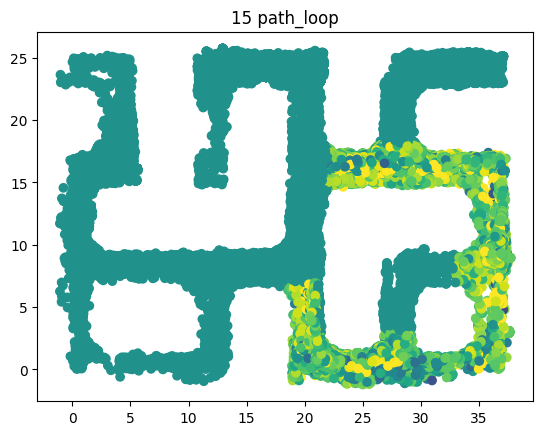

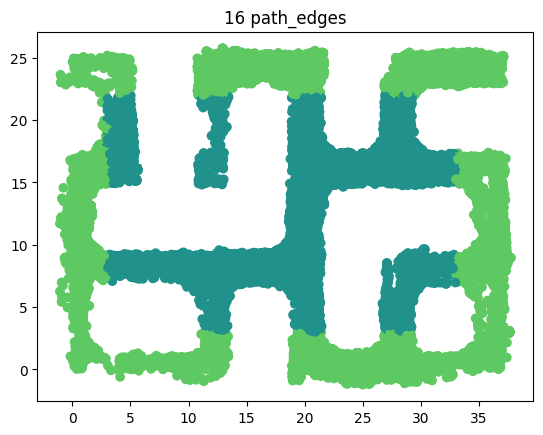

In [14]:
for i, (reward_function, test_label, param) in enumerate(benchmarks):
    
    
    # goal_reaching_reward(dataset_trajectories[:, ::10], reset_locations[2])
    
    rews = reward_function(dataset_trajectories[:, ::10], param)
    plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], c=rews, vmin=-1, vmax=1)
    
    
    # plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], c='gray')
    # i = 2
    # rews = reward_function(dataset_trajectories[i, ::10], param)
    # plt.scatter(dataset_trajectories[i, ::10, 0], dataset_trajectories[i, ::10, 1], c=rews, vmin=-1, vmax=1)
    
    plt.title(f'{i} {test_label}')
    plt.show()
    # break

In [3]:
(0.9**29) * 100_000

4710.1286972462485